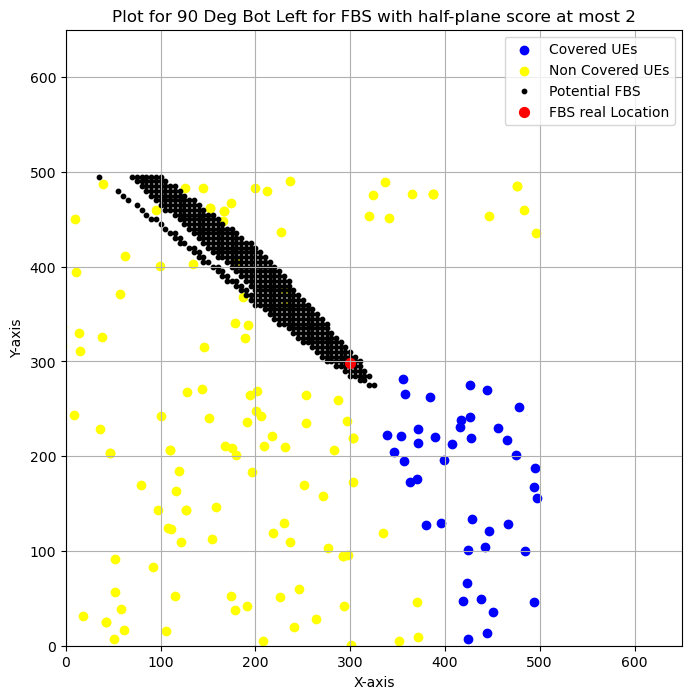

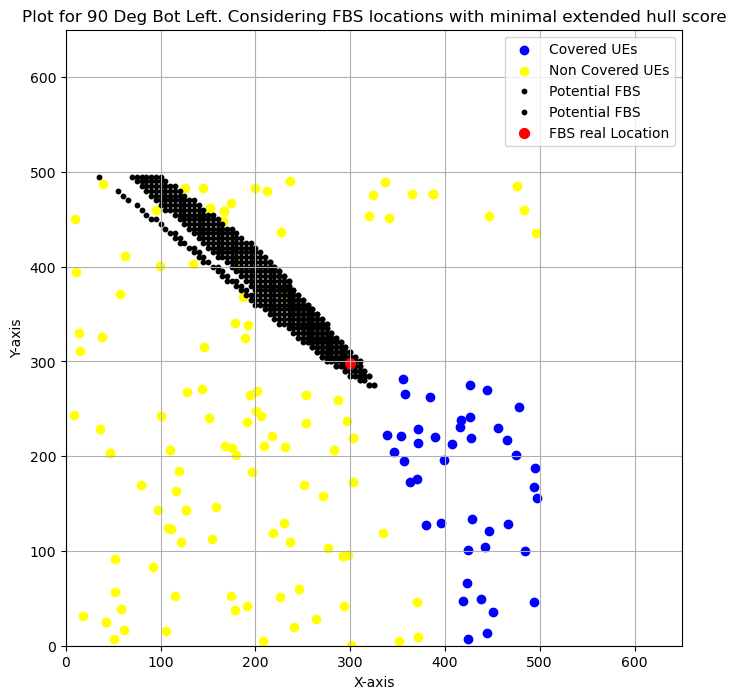

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
import math
import time
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib import pyplot as plt

#READ COVERED POINTS DATA (the data is collected in a folder named Data)


#120, order bot-Left -Right
#90, order bot-TopLeft-Top -Right


#dffbs = pd.read_csv('Score90DegBotApproxR20', header=None, names=['x', 'y', 'Score'], delimiter=',') 
#dfncov = pd.read_csv('NoSignalUE90DegBotApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',') 
#dfcov = pd.read_csv('SignalUE90DegBotApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')

#dffbs = pd.read_csv('Score90DegTopLeftApproxR20', header=None, names=['x', 'y', 'Score'], delimiter=',')
#dfncov = pd.read_csv('NoSignalUE90DegTopLeftApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')
#dfcov = pd.read_csv('SignalUE90DegTopLeftApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')

#dffbs = pd.read_csv('Score90DegTopApproxR20', header=None, names=['x', 'y', 'Score'], delimiter=',')
#dfncov = pd.read_csv('NoSignalUE90DegTopApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')
#dfcov = pd.read_csv('SignalUE90DegTopApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')

dffbs = pd.read_csv('Score90DegRightApproxR20', header=None, names=['x', 'y', 'Score'], delimiter=',')
dfncov = pd.read_csv('NoSignalUE90DegRightApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')
dfcov = pd.read_csv('SignalUE90DegRightApproxR20', header=None, names=['x', 'y', 'RSRP'], delimiter=',')

#Read FBS location, used to evaluate the error between real and estimated location
dfbsloc=pd.read_csv('FBSlocR20', header=None, names=['coor'], delimiter=',')




#Some parts of following are extra, some are used


xc = dfcov['x']
yc = dfcov['y']

#EXTRACT COVERED POINTS COORDINATES (BLUE POINTS)
Cov_coordinates = dfcov[['x', 'y']].to_numpy()


#READ NON-COVERED POINTS DATA


xnc = dfncov['x']
ync = dfncov['y']
RSRPc= dfcov['RSRP']

#EXTRACT NON-COVERED POINTS COORDINATES (YELLOW POINTS)
NonCov_coordinates = dfncov[['x', 'y']].to_numpy()









#Choose potential FBS locations with score <= X.
X=min(dffbs['Score'])+1
score100=dffbs[dffbs['Score'] <=  X]
xfbs = score100['x']
yfbs = score100['y']
scorefbs=score100['Score']
Scorefbs_reset = scorefbs.reset_index(drop=True)

#EXTRACT COOORDINATES OF POTENTIAL FBS WITH SCORE <= X.
FBS_coordinates = score100[['x', 'y']].to_numpy()


# FBS "real" location (RED POINT)



Xrfbs=dfbsloc['coor'].to_numpy()[0]
Yrfbs=dfbsloc['coor'].to_numpy()[1]



#Extract coordinates of points with halfplane score = value
def HPlaneCoord(dffbs,value):
    Hscore=dffbs[dffbs['Score'] ==  value]
    xcoorfbs = Hscore['x']
    ycoorfbs = Hscore['y']
    Hscorefbs=Hscore['Score']
    Scorefbs_reset = Hscorefbs.reset_index(drop=True)

    FBScoordinates = Hscore[['x', 'y']].to_numpy()

    return FBScoordinates


#Extract coordinates of points with halfplane score <= value
def HPlaneCoordAtmost(dffbs,value):
    Hscore=dffbs[dffbs['Score'] <=  value]
    xcoorfbs = Hscore['x']
    ycoorfbs = Hscore['y']
    Hscorefbs=Hscore['Score']
    Scorefbs_reset = Hscorefbs.reset_index(drop=True)

    FBScoordinates = Hscore[['x', 'y']].to_numpy()

    return FBScoordinates

#Extract halfplane score of a point  xCoor,yCoor
def HPlaneScore(dffbs,xCoor,yCoor) -> int:
    Hscore1=dffbs[dffbs['x'] ==  xCoor] 
    Hscore=Hscore1[Hscore1['y'] == yCoor]
 #   xcoorfbs = Hscore['x']
 #   ycoorfbs = Hscore['y']
 #   Hscorefbs=Hscore['Score']
  #  Scorefbs_reset = scorefbs.reset_index(drop=True)

    CoordScore = Hscore[['Score']].to_numpy()

    return CoordScore

#Function to test if a point is in the convex hull WITH AN ERROR "tolerance". If we set tolerance=0, then x in hull iff x is inside the hull or on the hull's boundary
def is_point_in_hull(point, hull, tolerance):
    # Each equation represents a facet of the hull: normal_vector * x + offset <= 0
    return np.all(np.dot(hull.equations[:, :-1], point) + hull.equations[:, -1] <= tolerance)

#Function constructing the list of extended hulls by FBS locations, i.e., for each black point P we compute the hull of the set Blue Points union P.

def CvxHulls(FBS_coordinates,Cov_coordinates):
    hulls=[]
    for i in range(len(FBS_coordinates)):
        P=np.vstack([FBS_coordinates[i], Cov_coordinates])
        # Compute the convex hull of the points
        hulls.append(ConvexHull(P))
    return hulls

# list of extended hulls
HullsList=CvxHulls(FBS_coordinates,Cov_coordinates)

# A function taking as input the list of extended hulls and the set of non-covered points (yellow), and return a list of scores, where the sscore is the number of yellow points in the hull.

def Scoringhulls(HullsList,NonCov_coordinates):
    Scores=[]
    for i in HullsList:
        k=0
        for j in range(len(NonCov_coordinates)):
            if is_point_in_hull(NonCov_coordinates[j], i, tolerance=0):
                k+=1
            else:
                k=k
        Scores.append(k)
    return Scores

# We compute S the list of scores.
S=Scoringhulls(HullsList,NonCov_coordinates)

#Next we need a function returning the potential FBS points with score less than some given value T.
#First we extract from the scores list S the indices of the scores less than T, then extract from the FBS_coordinates list the points with such indices.
#Note that indices in FBS_coordinates list is in one to one correspondence with the indicies in Hullslist, as every entry in Hullslist is defined by the FBS point used to extend Cov_coordinates hull. 
   
        
#Get the indicies of hulls with score less or equal than a value, here we take the value to be minimum score min(S).
def get_indices(lst, value):
    return [index for index, element in enumerate(lst) if element <= value]
S=Scoringhulls(HullsList,NonCov_coordinates)
indices = get_indices(S,min(S))


#Recover Potential points        
Potential=[]
for i in indices:
    Potential.append(FBS_coordinates[i])
coordinatesPot = np.vstack(Potential)


###
#'''
# (x1,y1) is the list of (potential) FBS coordinates with score less than value, here the score value is the min score. 
x1 = coordinatesPot[:, 0]
y1 = coordinatesPot[:, 1]    

# Plot the points
plt.figure(figsize=(12, 8))
plt.scatter(xc, yc, color='blue',label='Covered UEs', marker='o')
plt.scatter(xnc, ync, color='yellow', label='Non Covered UEs', marker='o')
plt.scatter(xfbs, yfbs, color='Black', label='Potential FBS', marker='o',s=10)

#plt.scatter(x1, y1, color='Black', label='Potential FBS', marker='o',s=10)

plt.scatter(Xrfbs, Yrfbs, color='red', label='FBS real Location', marker='o',s=50)

plt.xlim(0, 650)
plt.ylim(0, 650)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'Plot for 90 Deg Bot Left for FBS with half-plane score at most {X}')
plt.legend()
plt.grid(True)

# Plot the points
plt.figure(figsize=(12, 8))
plt.scatter(xc, yc, color='blue',label='Covered UEs', marker='o')
plt.scatter(xnc, ync, color='yellow', label='Non Covered UEs', marker='o')
plt.scatter(xfbs, yfbs, color='Black', label='Potential FBS', marker='o',s=10)
plt.scatter(x1, y1, color='Black', label='Potential FBS', marker='o',s=10)

plt.scatter(Xrfbs, Yrfbs, color='red', label='FBS real Location', marker='o',s=50)

plt.xlim(0, 650)
plt.ylim(0, 650)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot for 90 Deg Bot Left. Considering FBS locations with minimal extended hull score')
plt.legend()
plt.grid(True)

###
#you can save the plot using this line
#plt.savefig('Restrict.png', dpi=300, bbox_inches='tight')

# New hull Scoring 
### Fix a black point $P$, let $Cov$ be the set of blue points, $Noncov$ the set of yellow points.
### Above we considered $Hull_p(Cov)=Cvxhull(P \cup Cov)$, and our score is $Score(Hull_p(Cov))= \# (Noncov \cap Hull_p(Cov))$.
### Our goal now is to find a subset $SubCov\subseteq Cov$, such that
### $$Hull_p(SubCov)=Cvxhull(P \cup SubCov),$$ minimizing $Score(Hull_p(SubCov))+ card(Cov)-card(SubCov),$ where $Score(Hull_p(SubCov))= \# (Noncov \cap Hull_p(SubCov))$.
### To avoid considering all possible subsets, thus, we consider subsets with boundary points removed.

In [3]:
def cartesian_to_polar(point, origin):
    #Convert Cartesian coordinates to polar coordinates with respect to a new origin.
    x, y = point
    x_p, y_p = origin
    dx, dy = x - x_p, y - y_p
    r = math.sqrt(dx**2 + dy**2)
    theta = math.atan2(dy, dx)
    return r, theta



# Finding the min angle at a given point x covering the convex hull is finding the max angle at x and any two hull verticies.

#First, we need a function to compute the angle at a point x, given two points y and z.

def compute_angleatx(x, y, z):
   
    def distance(p1, p2):
        return math.hypot(p2[0] - p1[0], p2[1] - p1[1])

    # Compute the lengths of the sides opposite to each vertex
    a = distance(y, z)  # Length opposite vertex x
    b = distance(x, z)  # Length opposite vertex y
    c = distance(x, y)  # Length opposite vertex z

    # Check for degenerate triangle
    #if a + b <= c or a + c <= b or b + c <= a:
        #raise ValueError("The points do not form a valid triangle.")

    if b != 0 and c!=0:
        triangle = (b**2 + c**2 - a**2) / (2 * b * c)
        
        if triangle>1:
            triangle = 1

        if triangle <-1:
            triangle = -1

        
        angle_x = math.acos(triangle)
    else:
        angle_x = 0
  

    return np.degrees(angle_x)

# Next function is for finding the min angle at a given point x covering the convex hull, which consists of finding the max angle at x and any two 
# hull verticies.
def MinAngle(hull_points,x):
    L=[]
    I=[]
    for i in range(len(hull_points)):
        for j in range(i+1,len(hull_points)):
            L.append(compute_angleatx(x, hull_points[i], hull_points[j]))
            I.append([i,j])
        
    minAngle = max(L)

    # Find the points satisfying the min angle with x
    max_index = L.index(minAngle)
    i1=I[max_index][0]
    i2=I[max_index][1]

    itemp1=i1
    itemp2=i2
    
    pi1=cartesian_to_polar(hull_points[i1],x)[1]
    pi2=cartesian_to_polar(hull_points[i2],x)[1]

    if pi1<0 and pi2<0:
        if pi2<pi1:
            i2=itemp1
            i1=itemp2

    if pi1>0 and pi2>0:
        if pi2<pi1:
            i2=itemp1
            i1=itemp2

    if pi1<0 and pi2>0:
        if pi1<-math.pi / 2:
            i2=itemp1
            i1=itemp2

    if pi1>0 and pi2<0:
        if pi1<math.pi / 2:
            i2=itemp1
            i1=itemp2

    
            
    P1=hull_points[i1]
    P2=hull_points[i2]
    return minAngle, P1, P2 #returns the min angle and the hull vertices satisfying minangle with x


#To visualize the angle and the vertices above we generate the line passing through P1, P2
def Line(P1,P2):
    x1, y1 = P1
    x2, y2 = P2

# Calculate the slope (m) and intercept (b)
    if x2 - x1 != 0:
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        # Generate x and y values for plotting
        x_values = np.linspace(min(x1, x2) - 200, max(x1, x2) + 1, 100)
        y_values = m * x_values + b
    else:
    # Handle vertical line
        m = None
        b = None
        x_values = np.full(100, x1)
        y_values = np.linspace(min(y1, y2) - 200, max(y1, y2) + 1, 100)
    return x_values, y_values




In [4]:
def Scoringhulls(HullsList,NonCov_coordinates):
    Scores=[]
    for i in HullsList:
        k=0
        for j in range(len(NonCov_coordinates)):
            if is_point_in_hull(NonCov_coordinates[j], i, tolerance=0):
                k+=1
            else:
                k=k
        Card_cov_sub=len()
        Scores.append(k)
        
    return Scores

#A function taking as input a black point, the covered blue points and returning subsets of points with sides removed, 
#iterated for a number of times equal to some "bound" .At each iteration we remove two points, one from the left and one from the right
def Subsets(BP,Cov_coordinates,bound):
    SubsetList=[]
    P=np.vstack([BP, Cov_coordinates])
    SubsetList.append(P)
    for i in range(bound):
        P1=MinAngle(Cov_coordinates,BP)[1]
        P2=MinAngle(Cov_coordinates,BP)[2]
        mask = ~(np.all(Cov_coordinates == np.array(P1), axis=1))
        Cov_coordinates = Cov_coordinates[mask]
        mask = ~(np.all(Cov_coordinates == np.array(P2), axis=1))
        Cov_coordinates = Cov_coordinates[mask]
        P=np.vstack([BP, Cov_coordinates])
        SubsetList.append(P)
    return SubsetList
#please note that the first entry in the list, i.e., Subsets(BP,Cov_coordinates,bound)[0] is the set consisting of 
    #ALL Cov_coordinates union the black point BP.

def LSubsets(BP,Cov_coordinates,bound):
    SubsetList=[]
    P=np.vstack([BP, Cov_coordinates])
    SubsetList.append(P)
    for i in range(bound):
        P1=MinAngle(Cov_coordinates,BP)[1]
        mask = ~(np.all(Cov_coordinates == np.array(P1), axis=1))
        Cov_coordinates = Cov_coordinates[mask]
        P=np.vstack([BP, Cov_coordinates])
        SubsetList.append(P)
    return SubsetList

def RSubsets(BP,Cov_coordinates,bound):
    SubsetList=[]
    P=np.vstack([BP, Cov_coordinates])
    SubsetList.append(P)
    for i in range(bound):
        P2=MinAngle(Cov_coordinates,BP)[2]
        mask = ~(np.all(Cov_coordinates == np.array(P2), axis=1))
        Cov_coordinates = Cov_coordinates[mask]
        P=np.vstack([BP, Cov_coordinates])
        SubsetList.append(P)
    return SubsetList

In [5]:
# We need a function taking as input list of subsets for a fixed black point and the set nonCov, 
# then returns a list of scores (we are interested in the min score) 
def Scoringhullssubset(subsets,NonCov_coordinates):
    Card_cov=len(subsets[0]-1)
    Scores=[]
    for i in subsets:
        if len(i)>3:
            hull = ConvexHull(i)
            Card_subset=len(i)-1
            k=0
            for j in range(len(NonCov_coordinates)):
                if is_point_in_hull(NonCov_coordinates[j], hull, tolerance=0):
                    k+=1
                else:
                    k=k
            S=k+(Card_cov-Card_subset)
            Scores.append(S)
        
        else:
            S=Card_cov-Card_subset
            Scores.append(S)
    return Scores



In [6]:
#Function to compute the scores of FBS_coordinates, the variable "bound" is used to precise the number of times we remove points from the sides
#At each iteration we remove two points, one from the left and one from the right
def Pot_FBS(FBS_coordinates,Cov_coordinates,NonCov_coordinates,bound):
    Scores=[]
    for i in FBS_coordinates:
        subsetlist=Subsets(i,Cov_coordinates,bound)
        t=min(Scoringhullssubset(subsetlist,NonCov_coordinates))
        Scores.append(t)
    return Scores
        

def Pot_FBSsides(FBS_coordinates,Cov_coordinates,NonCov_coordinates,bound):
    Scores=[]
    for i in FBS_coordinates:

        hull = ConvexHull(Cov_coordinates)
        
        if is_point_in_hull(i,hull,0):
            hulllist=[]
            hulllist.append(hull)
            subsetlist=LSubsets(i,Cov_coordinates,0)
            inHullScore=1
            t2=min(Scoringhullssubset(subsetlist,NonCov_coordinates))+inHullScore        
        else:
            inHullScore=0
            
            subsetlist=LSubsets(i,Cov_coordinates,bound)
            scores1=Scoringhullssubset(subsetlist,NonCov_coordinates)
            t=min(scores1)
            for j in range(len(scores1)):
                 if t==scores1[j]:
                     subsetlist2=RSubsets(i,subsetlist[j],bound)
                     t2=min(Scoringhullssubset(subsetlist2,NonCov_coordinates))+inHullScore
                     break
        Scores.append(t2)
    return Scores


predicted [279.0625 306.5625] real location [299.733, 298.603] Error 22.150016038
HP predicted [275. 310.] real location [299.733, 298.603] Error 27.232570536


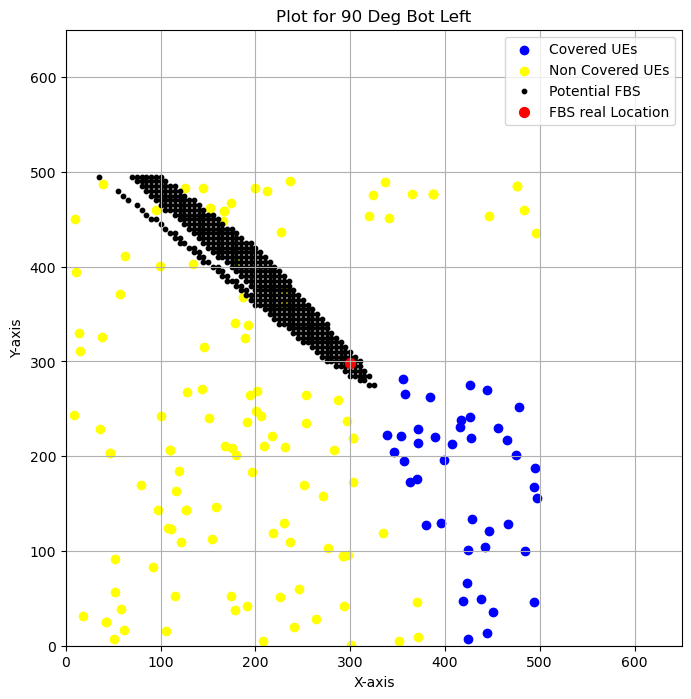

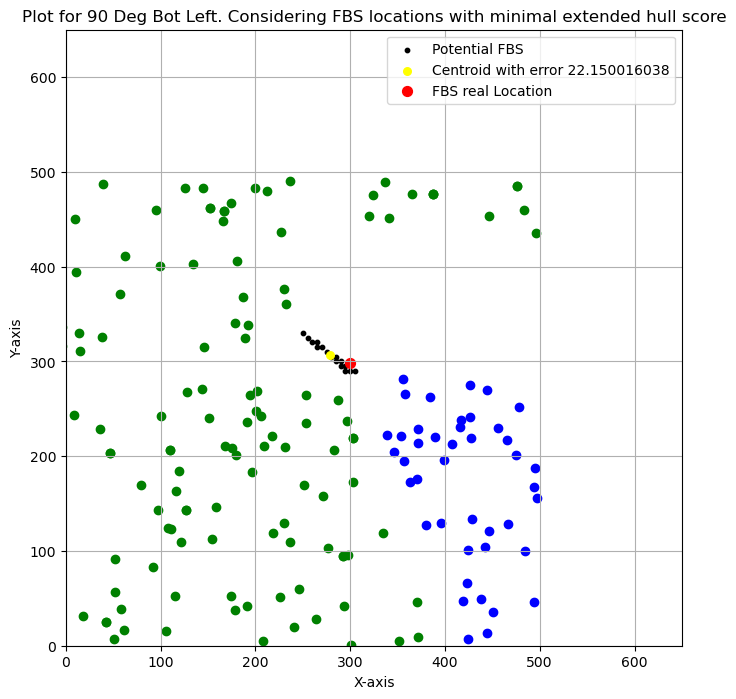

In [7]:
def get_indices(lst, value):
    return [index for index, element in enumerate(lst) if element <= value]
# We consider n iterations, that results in the last subset containing Card(Cov) minus 2n points. 

minHplane=min(dffbs['Score'])


S1=Pot_FBSsides(HPlaneCoord(dffbs,minHplane),Cov_coordinates,NonCov_coordinates,1)
S2=Pot_FBSsides(HPlaneCoord(dffbs,minHplane),Cov_coordinates,NonCov_coordinates,min(S1))

#Maximum halfplane score we need to consider
HalfplaneBoundScore = min(S2)+minHplane

S=Pot_FBSsides(HPlaneCoordAtmost(dffbs,HalfplaneBoundScore),Cov_coordinates,NonCov_coordinates,min(S2))


#Total score of points
Stot=[]
for i in range(len(HPlaneCoordAtmost(dffbs,HalfplaneBoundScore))):
    Stot.append(S[i]+HPlaneScore(dffbs,HPlaneCoordAtmost(dffbs,HalfplaneBoundScore)[i,0],HPlaneCoordAtmost(dffbs,HalfplaneBoundScore)[i,1])[0,0])

indices = get_indices(Stot,min(Stot))





#Initial Potential points        
Potential=[]
for i in indices:
    Potential.append(HPlaneCoordAtmost(dffbs,HalfplaneBoundScore)[i])
coordinatesPot = np.vstack(Potential)

centerpoint=np.mean(coordinatesPot, axis=0)

centerpx=centerpoint[0]
centerpy=centerpoint[1]


FBS=[Xrfbs, Yrfbs]
LocErr=round(math.dist(centerpoint,FBS),9)
print("predicted",centerpoint,"real location",FBS,"Error",LocErr)


HplanePotLoc1=dffbs[dffbs['Score'] <=  minHplane]
HplanePotLoc=HplanePotLoc1[['x', 'y']].to_numpy()
centerHPPot=np.mean(HplanePotLoc, axis=0)
LocErrHplane=round(math.dist(centerHPPot,FBS),9)
print("HP predicted",centerHPPot,"real location",FBS,"Error",LocErrHplane)



# (x1,y1) is the list of (potential) FBS coordinates with score less than value. 
x1 = coordinatesPot[:, 0]
y1 = coordinatesPot[:, 1] 


xp = HPlaneCoordAtmost(dffbs,HalfplaneBoundScore)[:,0]
yp = HPlaneCoordAtmost(dffbs,HalfplaneBoundScore)[:,1]








# Plot the points
plt.figure(figsize=(12, 8))
plt.scatter(xc, yc, color='blue',label='Covered UEs', marker='o')
plt.scatter(xnc, ync, color='yellow', label='Non Covered UEs', marker='o')
plt.scatter(xp, yp, color='Black', label='Potential FBS', marker='o',s=10)

#plt.scatter(x1, y1, color='Black', label='Potential FBS', marker='o',s=10)

plt.scatter(Xrfbs, Yrfbs, color='red', label='FBS real Location', marker='o',s=50)

plt.xlim(0, 650)
plt.ylim(0, 650)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot for 90 Deg Bot Left')
plt.legend()
plt.grid(True)

# Plot the points
plt.figure(figsize=(12, 8))
plt.scatter(xc, yc, color='blue', marker='o')
plt.scatter(xnc, ync, color='Green', marker='o')
#plt.scatter(xfbs, yfbs, color='Black', label='Potential FBS', marker='o',s=10)
plt.scatter(x1, y1, color='Black', label='Potential FBS', marker='o',s=10)
plt.scatter(centerpx, centerpy, color='Yellow', label=f'Centroid with error {LocErr}', marker='o',s=30)

plt.scatter(Xrfbs, Yrfbs, color='red', label='FBS real Location', marker='o',s=50)

plt.xlim(0, 650)
plt.ylim(0, 650)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot for 90 Deg Bot Left. Considering FBS locations with minimal extended hull score')
plt.legend()
plt.grid(True)

f = open("ErrorLoc90HP3Log1.txt", "a")
f.write(f',{LocErrHplane}')
f.close()


f = open("ErrorLoc90CH3Log1.txt", "a")
f.write(f',{LocErr}')
f.close()

